In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

#file_results = "risultati_MCMC.csv"
#file_results = "risultati_MCMC_linee_eliminate.csv"

#file_results = "risultati_osterbrock.csv"
file_results = "risultati_osterbrock_linee_eliminate.csv"
df = pd.read_csv(file_results)

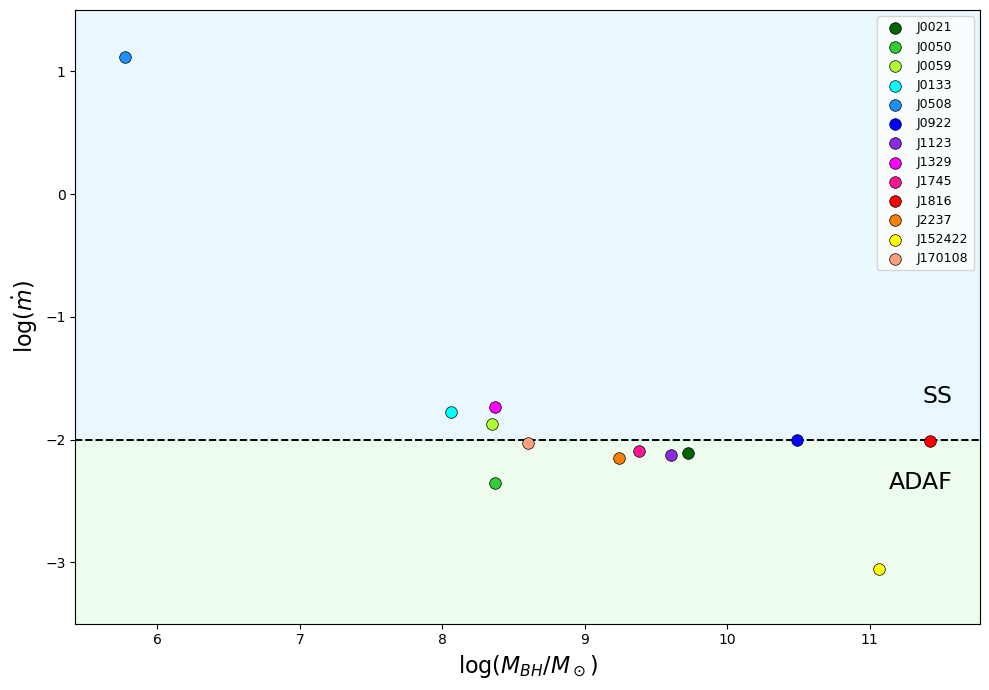

In [13]:
# ============================================================
# Accretion rate vs black-hole mass
# ============================================================
required_columns = {"Blazar", "m_median_Msun", "mdot_median"}
missing_columns = required_columns - set(df.columns)

if missing_columns:
    raise ValueError(
        f"Mancano nel CSV le seguenti colonne richieste: {sorted(missing_columns)}"
    )

df

blazar_order = ['J0021', 'J0050', 'J0059', 'J0133', 'J0508', 'J0922', 'J1123', 'J1329', 'J1745', 'J1816', 'J2237', 'J152422', 'J170108']
colors = ['#006400', '#32cd32', '#adff2f', '#00ffff', '#1e90ff', '#0000ff', '#8a2be2', '#ff00ff', '#ff1493', '#ff0000', '#ff7f00', '#ffff00', '#ffa07a']
color_map = dict(zip(blazar_order, colors))
color_map

# Calcolo dei logaritmi in base 10
df["log_m_bh"] = np.log10(df["m_median_Msun"])
df["log_mdot"] = np.log10(df["mdot_median"])

# Limiti degli assi con un piccolo margine
x_min = df["log_m_bh"].min() - 0.35
x_max = df["log_m_bh"].max() + 0.35
y_min = min(df["log_mdot"].min() - 0.35, -3.5)
y_max = max(df["log_mdot"].max() + 0.35, 1.5)

fig, ax = plt.subplots(figsize=(10, 7))

# Aree dei due regimi con tonalità molto leggere
ax.axhspan(-2, y_max, color="lightskyblue", alpha=0.16, zorder=0)
ax.axhspan(y_min, -2, color="lightgreen", alpha=0.16, zorder=0)

# Riga di switch ADAF/SS
ax.axhline(-2, color="black", linestyle="--", linewidth=1.4, zorder=1)

# Un punto per ogni blazar, con il colore richiesto
for _, row in df.iterrows():
    blazar = row["Blazar"]
    point_color = color_map.get(blazar, "black")

    ax.scatter(
        row["log_m_bh"],
        row["log_mdot"],
        s=70,
        color=point_color,
        edgecolor="black",
        linewidth=0.5,
        label=blazar,
        zorder=3
    )

# Nomi dei regimi sulla destra, sopra e sotto la linea di switch
x_text = x_max - 0.03 * (x_max - x_min)

ax.text(
    x_text, -1.65, "SS",
    ha="right", va="center",
    fontsize=17, color="black"
)

ax.text(
    x_text, -2.35, "ADAF",
    ha="right", va="center",
    fontsize=17, color="black"
)

# Etichette degli assi
ax.set_xlabel(r"$\log(M_{BH}/M_\odot)$", fontsize=16)
ax.set_ylabel(r"$\log(\dot{m})$", fontsize=16)

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

# Legenda interna, in alto a destra
ax.legend(
    loc="upper right",
    fontsize=9,
    frameon=True,
    ncol=1
)

plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# Correlation between log(M_BH/M_sun) and log(mdot)
# ============================================================

x = df["log_m_bh"]
y = df["log_mdot"]

pearson_r, pearson_p = pearsonr(x, y)
spearman_rho, spearman_p = spearmanr(x, y)

print("Correlation between log(M_BH/M_sun) and log(mdot)")
print("--------------------------------------------------")
print(f"Pearson r   = {pearson_r:.3f}")
print(f"Pearson p   = {pearson_p:.3e}")
print(f"Spearman rho = {spearman_rho:.3f}")
print(f"Spearman p   = {spearman_p:.3e}")

Correlation between log(M_BH/M_sun) and log(mdot)
--------------------------------------------------
Pearson r   = -0.768
Pearson p   = 2.164e-03
Spearman rho = -0.560
Spearman p   = 4.635e-02


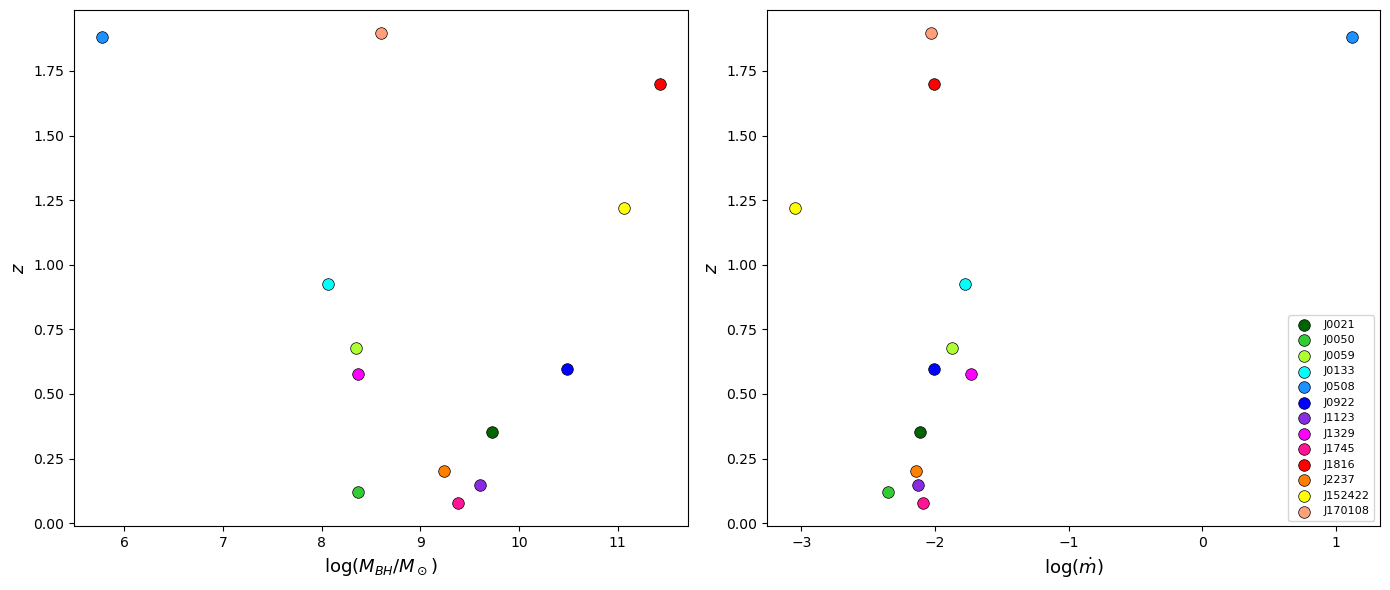

In [15]:
# ============================================================
# Redshift vs black-hole mass and accretion rate
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

# ------------------------------------------------------------
# LEFT: z vs log(M_BH / M_sun)
# ------------------------------------------------------------

for _, row in df.iterrows():

    blazar = row["Blazar"]
    point_color = color_map.get(blazar, "black")

    axes[0].scatter(
        row["log_m_bh"],
        row["z"],
        s=70,
        color=point_color,
        edgecolor="black",
        linewidth=0.5,
        label=blazar
    )

axes[0].set_xlabel(
    r"$\log(M_{BH}/M_\odot)$",
    fontsize=13
)

axes[0].set_ylabel(
    r"$z$",
    fontsize=13
)




# ------------------------------------------------------------
# RIGHT: z vs log(mdot)
# ------------------------------------------------------------

for _, row in df.iterrows():

    blazar = row["Blazar"]
    point_color = color_map.get(blazar, "black")

    axes[1].scatter(
        row["log_mdot"],
        row["z"],
        s=70,
        color=point_color,
        edgecolor="black",
        linewidth=0.5,
        label=blazar
    )

axes[1].set_xlabel(
    r"$\log(\dot{m})$",
    fontsize=13
)

axes[1].set_ylabel(
    r"$z$",
    fontsize=13
)


axes[1].legend(
    loc="lower right",
    fontsize=8,
    frameon=True
)


plt.tight_layout()
plt.show()

In [16]:
# ------------------------------------------------------------
# 1) Redshift vs log(M_BH / M_sun)
# ------------------------------------------------------------

x_mass = df["log_m_bh"]
y_z = df["z"]

pearson_r_mass_z, pearson_p_mass_z = pearsonr(x_mass, y_z)
spearman_rho_mass_z, spearman_p_mass_z = spearmanr(x_mass, y_z)

print("Correlation between log(M_BH/M_sun) and redshift")
print("------------------------------------------------")
print(f"Pearson r     = {pearson_r_mass_z:.3f}")
print(f"Pearson p     = {pearson_p_mass_z:.3e}")
print(f"Spearman rho  = {spearman_rho_mass_z:.3f}")
print(f"Spearman p    = {spearman_p_mass_z:.3e}")

print()


# ------------------------------------------------------------
# 2) Redshift vs log(mdot)
# ------------------------------------------------------------

x_mdot = df["log_mdot"]

pearson_r_mdot_z, pearson_p_mdot_z = pearsonr(x_mdot, y_z)
spearman_rho_mdot_z, spearman_p_mdot_z = spearmanr(x_mdot, y_z)

print("Correlation between log(mdot) and redshift")
print("------------------------------------------")
print(f"Pearson r     = {pearson_r_mdot_z:.3f}")
print(f"Pearson p     = {pearson_p_mdot_z:.3e}")
print(f"Spearman rho  = {spearman_rho_mdot_z:.3f}")
print(f"Spearman p    = {spearman_p_mdot_z:.3e}")

Correlation between log(M_BH/M_sun) and redshift
------------------------------------------------
Pearson r     = -0.150
Pearson p     = 6.254e-01
Spearman rho  = -0.099
Spearman p    = 7.479e-01

Correlation between log(mdot) and redshift
------------------------------------------
Pearson r     = 0.438
Pearson p     = 1.345e-01
Spearman rho  = 0.445
Spearman p    = 1.275e-01
